# 0. Project Overview

## Prediksi Permeabilitas Molekul terhadap Membran Lipid Bilayer Menggunakan Machine Learning Berbasis Deskriptor Fisikokimia

Notebook ini digunakan sebagai **demo utama** proyek. Fokus proyek adalah memprediksi apakah suatu molekul memiliki **low/moderate permeability** atau **high permeability** terhadap membran lipid bilayer berdasarkan deskriptor fisikokimia dari struktur molekul.

**Inti biologinya:** membran plasma bersifat selektif. Molekul yang lebih hidrofobik/lipofilik cenderung lebih mudah berinteraksi dengan bagian hidrofobik lipid bilayer, sedangkan molekul yang sangat polar, bermuatan, atau terlalu besar cenderung lebih sulit melewati membran secara pasif.

**Inti komputasinya:** struktur molekul dalam format **SMILES** diubah menjadi fitur numerik menggunakan RDKit, lalu fitur tersebut digunakan oleh model machine learning untuk klasifikasi permeabilitas.

Alur notebook:
1. Setup path proyek
2. Load dataset
3. Dataset summary
4. Feature extraction
5. Descriptor EDA
6. Model training
7. Model evaluation
8. Model interpretation
9. New SMILES prediction
10. Conclusion

In [20]:
from pathlib import Path
import os
import sys
import json
import pandas as pd
from IPython.display import display, Image

# Pastikan notebook selalu berjalan dari root project,
# bukan dari folder notebooks/, agar output tidak nyasar ke notebooks/results atau notebooks/models.
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SRC_DIR = PROJECT_ROOT / "src"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_TABLES_DIR = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

RAW_DATA_PATH = DATA_RAW_DIR / "pampa_ncats_raw.csv"
FEATURES_PATH = DATA_PROCESSED_DIR / "pampa_features.csv"

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_PATH)
print("Raw data exists:", RAW_DATA_PATH.exists())

Current working directory: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml
Project root: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml
Raw data path: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\data\raw\pampa_ncats_raw.csv
Raw data exists: True


# 1. Load Dataset

Dataset yang digunakan adalah **PAMPA_NCATS**, yaitu dataset permeabilitas molekul berbasis SMILES. Dataset ini digunakan sebagai masalah **klasifikasi biner**:

- `0` = Low/Moderate Permeability
- `1` = High Permeability

Pada demo ini, data dibaca dari file lokal agar program dapat dijalankan ulang tanpa harus mengambil data dari internet setiap kali notebook dijalankan.

In [21]:
# Jalankan tahap 01: data preparation.
# Tahap ini membaca dataset lokal, menstandarkan kolom, memeriksa missing value,
# membuat ringkasan dataset, dan membuat grafik distribusi label.
%run src/01_data_preparation.py

[INFO] Membaca dataset lokal: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\data\raw\pampa_ncats_raw.csv
[INFO] Jumlah data awal        : 2034
[INFO] Jumlah data setelah cek : 2034
[INFO] Data dihapus           : 0
[INFO] Dataset standar disimpan ke: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\data\raw\pampa_ncats_raw.csv
[INFO] Ringkasan dataset disimpan ke: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\results\tables\dataset_summary.csv
[INFO] Grafik distribusi label disimpan ke: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\results\figures\label_distribution.png

[INFO] Data preparation selesai.

[INFO] Preview data:
  Drug_ID                                             SMILES  Y
0   mol_0                         CCCCOC1=CC=C(C=C1)CC(=O)NO  1
1   mol_1            COC1=C(C=C(C=C1)CCN2C(=CC(=O)NC2=S)N)OC  0
2   mol_2  COC1=C(C=C(C=C1)Cl)C(=O)NC2=CC=C(C=C2)NC(=O

In [22]:
raw_df = pd.read_csv(RAW_DATA_PATH)

print("Dataset berhasil dimuat.")
print("Shape dataset:", raw_df.shape)
print("Kolom dataset:", list(raw_df.columns))

display(raw_df.head())

Dataset berhasil dimuat.
Shape dataset: (2034, 3)
Kolom dataset: ['Drug_ID', 'SMILES', 'Y']


,Drug_ID,SMILES,Y
0,mol_0,CCCCOC1=CC=C(C=C1)CC(=O)NO,1
1,mol_1,COC1=C(C=C(C=C1)CCN2C(=CC(=O)NC2=S)N)OC,0
2,mol_2,COC1=C(C=C(C=C1)Cl)C(=O)NC2=CC=C(C=C2)NC(=O)C3...,1
3,mol_3,CC(C)(C)N1C2=NC=NC(=C2C(=N1)C3=CC=C(C=C3)Cl)N,1
4,mol_4,CN1C2=CC=CC=C2C(=O)C3=C1N=C(N(C3=O)C4=CC=CC=C4...,1


# 2. Dataset Summary

Bagian ini menunjukkan kondisi awal dataset. Pemeriksaan distribusi label penting karena dataset PAMPA_NCATS tidak seimbang: jumlah molekul **High Permeability** lebih banyak dibanding **Low/Moderate Permeability**.

Karena itu, evaluasi model tidak cukup hanya menggunakan **accuracy**. Notebook ini juga menampilkan **Macro-F1**, **Balanced Accuracy**, **Recall per kelas**, **Confusion Matrix**, dan **ROC-AUC**.

In [23]:
dataset_summary_path = RESULTS_TABLES_DIR / "dataset_summary.csv"

if dataset_summary_path.exists():
    dataset_summary = pd.read_csv(dataset_summary_path)
    display(dataset_summary)
else:
    print("dataset_summary.csv belum ditemukan. Pastikan 01_data_preparation.py berhasil dijalankan.")

,metric,value
0,dataset_name,PAMPA_NCATS
1,n_rows,2034
2,n_columns,3
3,n_unique_smiles,2034
4,n_duplicate_smiles,0
5,missing_drug_id,0
6,missing_smiles,0
7,missing_target,0
8,class_0_count_low_moderate,295
9,class_1_count_high,1739


In [24]:
label_counts = raw_df["Y"].value_counts().sort_index()
label_percentages = raw_df["Y"].value_counts(normalize=True).sort_index() * 100

label_summary = pd.DataFrame({
    "Label": label_counts.index,
    "Description": ["Low/Moderate Permeability", "High Permeability"],
    "Count": label_counts.values,
    "Percentage (%)": label_percentages.round(2).values
})

display(label_summary)

,Label,Description,Count,Percentage (%)
0,0,Low/Moderate Permeability,295,14.5
1,1,High Permeability,1739,85.5


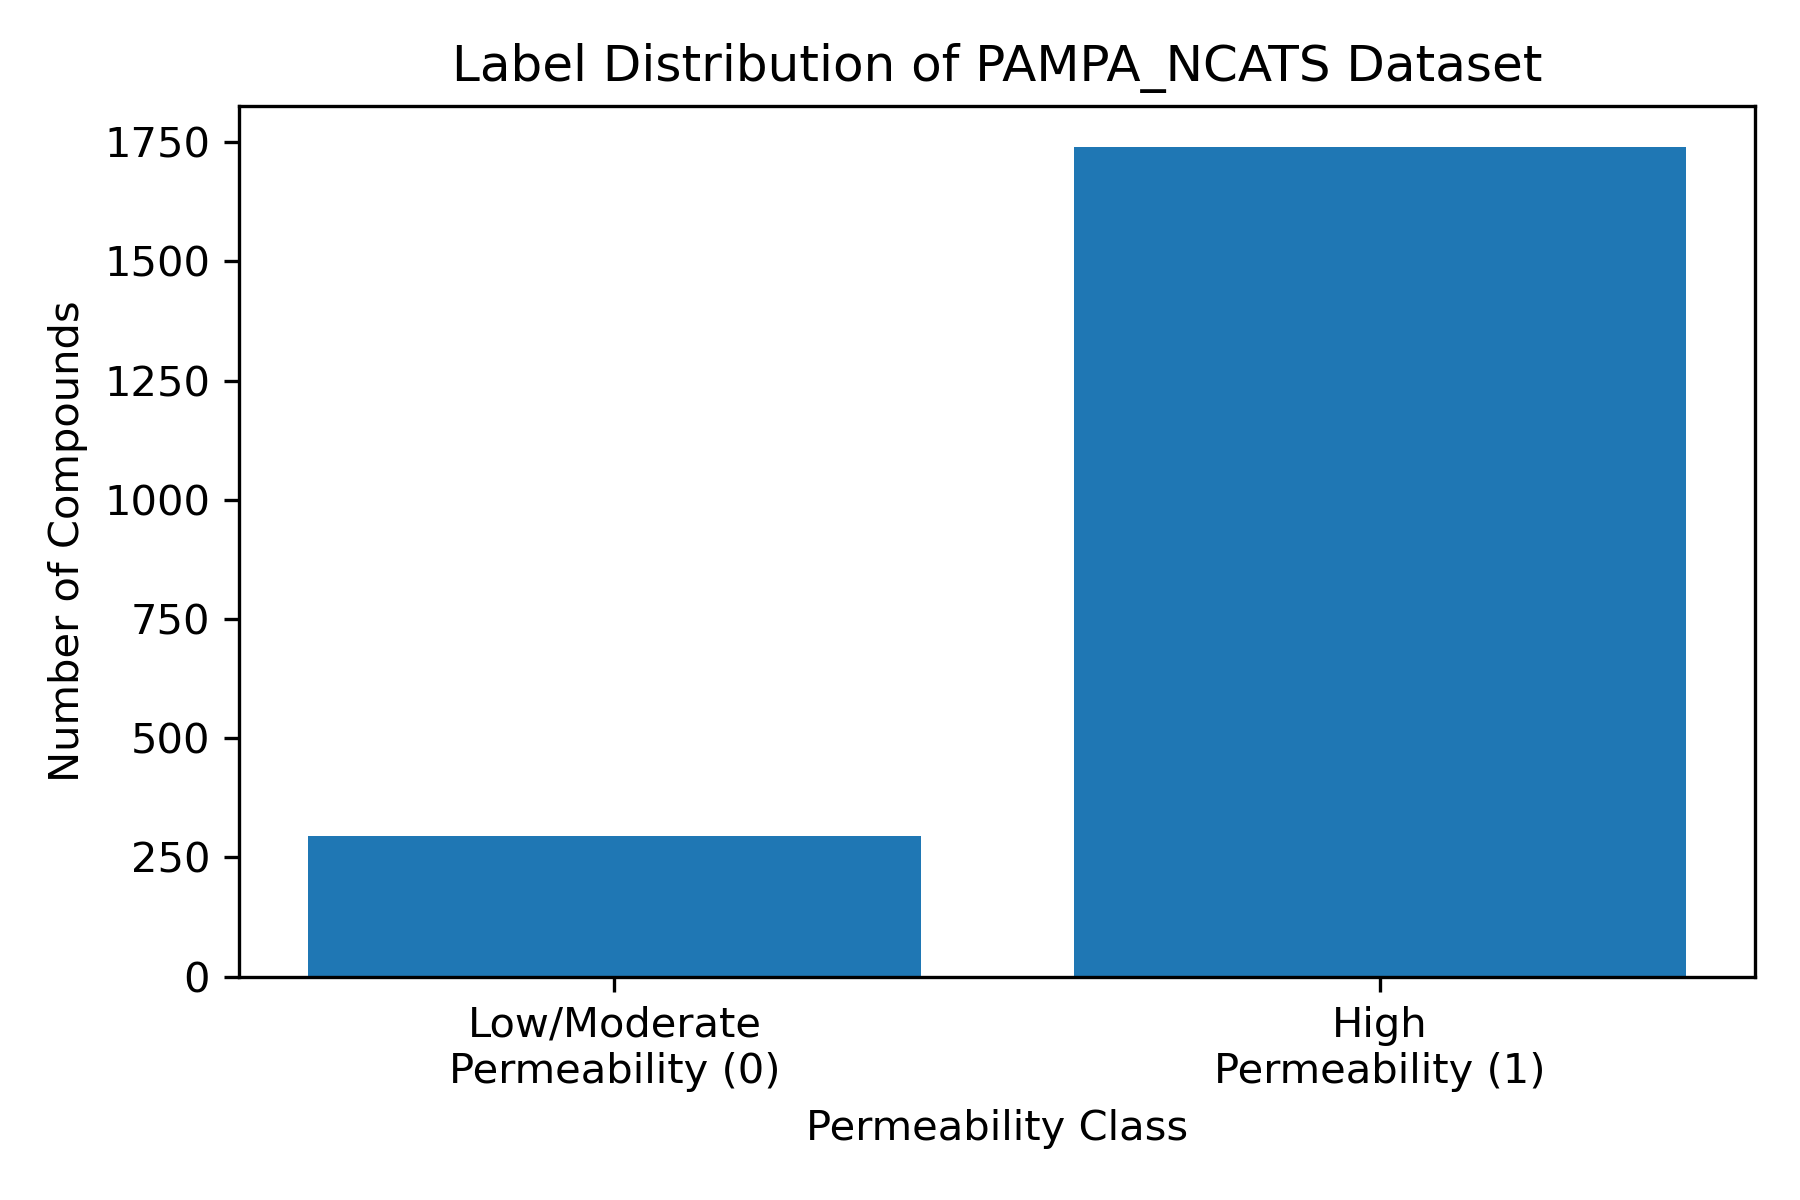

In [25]:
label_distribution_path = RESULTS_FIGURES_DIR / "label_distribution.png"

if label_distribution_path.exists():
    display(Image(filename=str(label_distribution_path)))
else:
    print("label_distribution.png belum ditemukan.")

# 3. Feature Extraction

Input awal dataset adalah **SMILES**, yaitu representasi struktur molekul dalam bentuk teks. SMILES tidak langsung digunakan oleh model, sehingga perlu diubah menjadi fitur numerik.

Pada tahap ini, RDKit digunakan untuk:
1. memvalidasi SMILES;
2. menghapus SMILES yang tidak valid;
3. menghitung deskriptor fisikokimia molekul.

Fitur yang digunakan:
- `MolWt`
- `LogP`
- `TPSA`
- `HBD`
- `HBA`
- `RotatableBonds`
- `HeavyAtomCount`
- `RingCount`
- `FormalCharge`

Fitur-fitur ini dipilih karena berkaitan dengan ukuran, lipofilisitas, polaritas, fleksibilitas, kompleksitas, bentuk, dan muatan molekul.

In [26]:
# Jalankan tahap 02: feature engineering.
# Tahap ini mengubah SMILES menjadi deskriptor molekuler numerik.
%run src/02_feature_engineering.py

[INFO] Dataset dimuat: 2034 baris, kolom: ['Drug_ID', 'SMILES', 'Y']
[INFO] Memvalidasi SMILES ...
[INFO]   Total    : 2034
[INFO]   Valid    : 2034
[INFO]   Invalid  : 0 (dihapus)
[INFO] Mengekstraksi deskriptor molekuler ...
[INFO] Ekstraksi selesai. Total baris: 2034

[INFO] Dataset fitur disimpan ke: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\data\processed\pampa_features.csv
[INFO] Shape: (2034, 12)
[INFO] Kolom: ['Drug_ID', 'SMILES', 'MolWt', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds', 'HeavyAtomCount', 'RingCount', 'FormalCharge', 'Y']

[INFO] Ringkasan deskriptor disimpan ke: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\results\tables\descriptor_summary.csv
[INFO] Membuat grafik distribusi deskriptor ...
[INFO] Grafik disimpan ke: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\results\figures\descriptor_distribution.png

[INFO] Preview 5 baris pertama:
Drug_ID                    

In [27]:
features_df = pd.read_csv(FEATURES_PATH)

print("Data fitur berhasil dimuat.")
print("Shape data fitur:", features_df.shape)

display(features_df.head())

Data fitur berhasil dimuat.
Shape data fitur: (2034, 12)


,Drug_ID,SMILES,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,HeavyAtomCount,RingCount,FormalCharge,Y
0,mol_0,CCCCOC1=CC=C(C=C1)CC(=O)NO,223.272,1.91340,58.56,2,3,6,16,1,0,1
1,mol_1,COC1=C(C=C(C=C1)CCN2C(=CC(=O)NC2=S)N)OC,307.375,1.74799,82.27,2,5,5,21,2,0,0
2,mol_2,COC1=C(C=C(C=C1)Cl)C(=O)NC2=CC=C(C=C2)NC(=O)C3...,370.792,4.44620,80.57,2,4,5,26,3,0,1
3,mol_3,CC(C)(C)N1C2=NC=NC(=C2C(=N1)C3=CC=C(C=C3)Cl)N,301.781,3.48390,69.62,1,4,1,21,3,0,1
4,mol_4,CN1C2=CC=CC=C2C(=O)C3=C1N=C(N(C3=O)C4=CC=CC=C4...,385.467,4.28530,56.89,0,3,2,29,5,0,1


# 4. Descriptor EDA

Descriptor EDA digunakan untuk memahami distribusi fitur molekuler. Bagian ini membantu menjelaskan hubungan antara fitur kimia dan konsep biologis membran.

Contoh:
- `LogP` berkaitan dengan lipofilisitas/hidrofobisitas.
- `TPSA`, `HBD`, dan `HBA` berkaitan dengan polaritas dan kemampuan membentuk ikatan hidrogen.
- `MolWt` dan `HeavyAtomCount` berkaitan dengan ukuran/kompleksitas molekul.
- `FormalCharge` berkaitan dengan muatan molekul.

In [28]:
descriptor_summary_path = RESULTS_TABLES_DIR / "descriptor_summary.csv"

if descriptor_summary_path.exists():
    descriptor_summary = pd.read_csv(descriptor_summary_path)
    display(descriptor_summary)
else:
    print("descriptor_summary.csv belum ditemukan.")

,feature,mean,std,min,Q1,median,Q3,max
0,MolWt,397.6497,83.7451,136.1140,344.4158,393.4250,445.5795,974.6340
1,LogP,3.8513,1.3179,-2.1729,3.0304,3.8736,4.7136,8.8332
2,TPSA,77.2736,27.9165,6.4800,58.8825,75.3200,94.1300,236.8100
3,HBD,1.4543,0.9739,0.0000,1.0000,1.0000,2.0000,8.0000
4,HBA,4.8378,1.6671,1.0000,4.0000,5.0000,6.0000,15.0000
5,RotatableBonds,4.8122,2.3612,0.0000,3.0000,5.0000,6.0000,21.0000
6,HeavyAtomCount,27.9867,5.8736,10.0000,24.0000,28.0000,31.0000,65.0000
7,RingCount,3.8147,0.9731,0.0000,3.0000,4.0000,4.0000,9.0000
8,FormalCharge,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


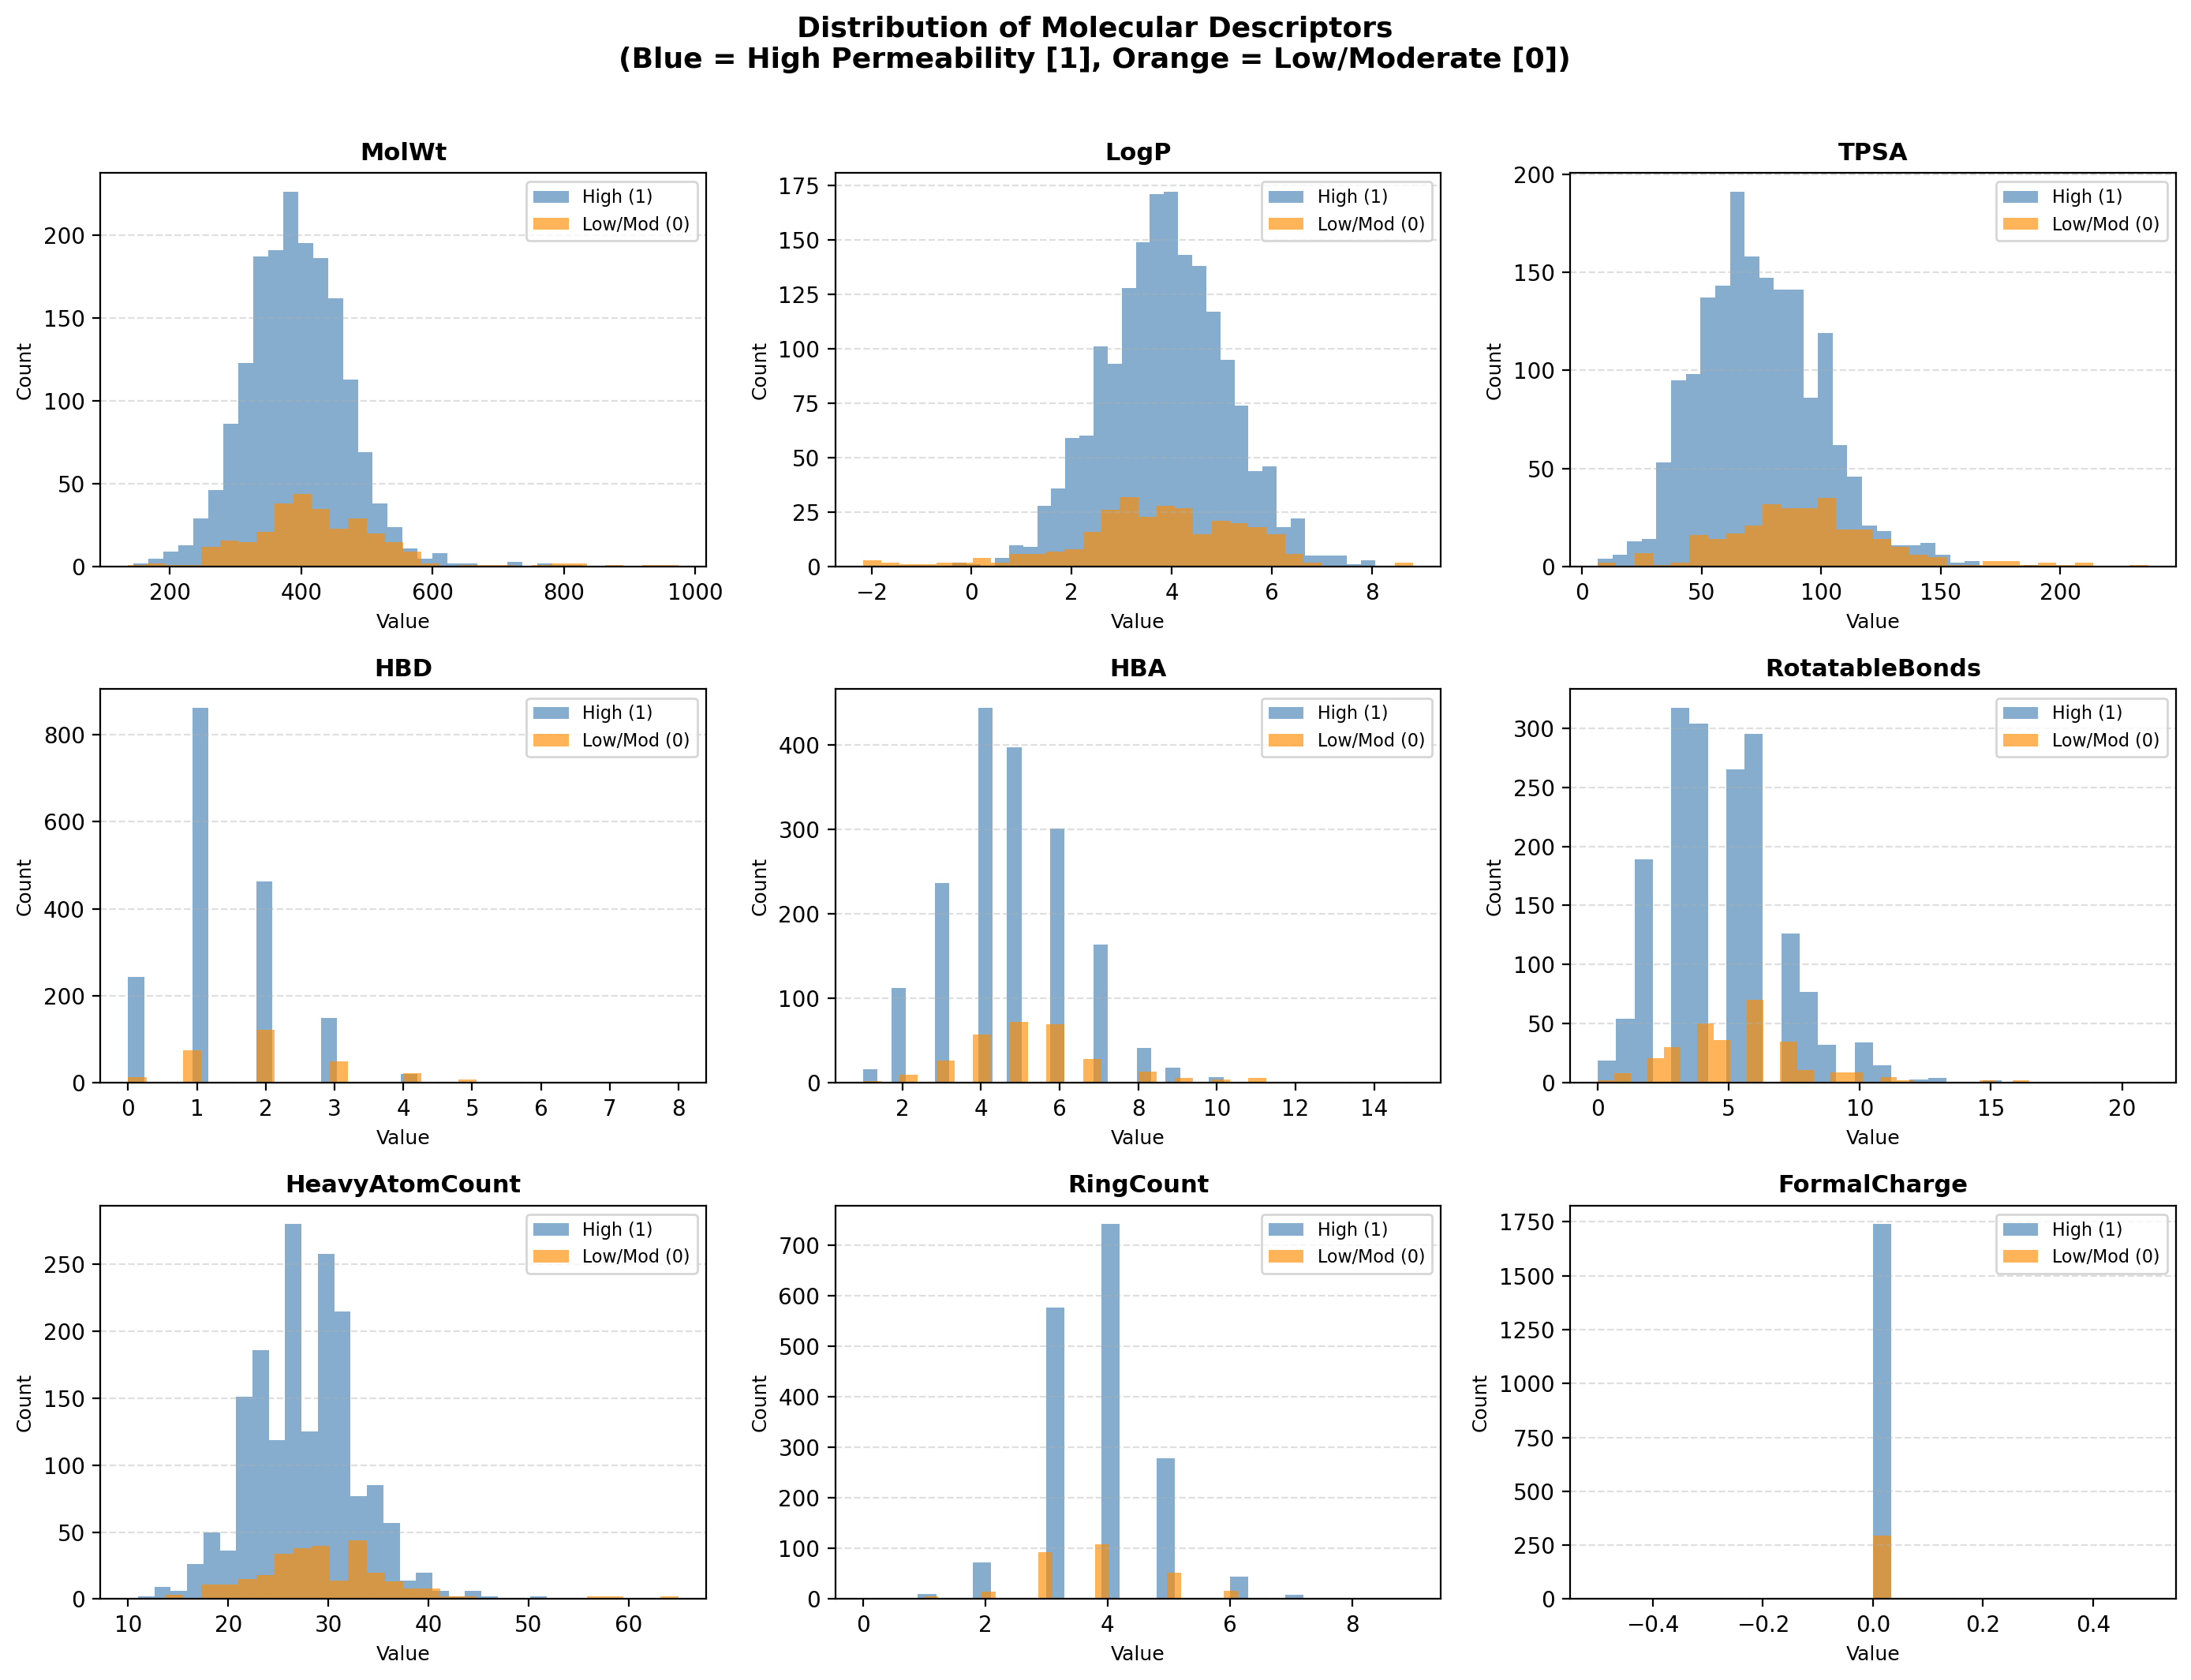

In [29]:
descriptor_distribution_path = RESULTS_FIGURES_DIR / "descriptor_distribution.png"

if descriptor_distribution_path.exists():
    display(Image(filename=str(descriptor_distribution_path)))
else:
    print("descriptor_distribution.png belum ditemukan.")

# 5. Model Training

Pada tahap ini, beberapa model klasifikasi dilatih dan dibandingkan. Model yang digunakan meliputi baseline dan model pembanding:

- Dummy Most Frequent
- Logistic Regression
- Logistic Regression Balanced
- Random Forest
- Random Forest Balanced
- Support Vector Machine
- XGBoost atau Gradient Boosting

Dummy classifier digunakan sebagai baseline sederhana. Ini penting karena dataset tidak seimbang; model yang selalu menebak kelas mayoritas bisa terlihat memiliki accuracy tinggi.

In [30]:
# Jalankan tahap 03: modeling.
# Tahap ini melakukan training, evaluasi, pemilihan best model,
# serta menyimpan confusion matrix dan ROC curve.
%run src/03_modeling.py

[INFO] Direktori output berhasil disiapkan.
[INFO] Data berhasil dimuat dari: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\data\processed\pampa_features.csv
[INFO] Jumlah data: 2034
[INFO] Train shape: (1627, 9), Test shape: (407, 9)
[INFO] Distribusi kelas total:
Y
Low/Moderate Permeability     295
High Permeability            1739
[INFO] Distribusi kelas test:
Y
Low/Moderate Permeability     59
High Permeability            348

[START] Melatih dan mengevaluasi model...
[INFO] Melatih Dummy Most Frequent...
[INFO] Melatih Logistic Regression...
[INFO] Melatih Logistic Regression Balanced...
[INFO] Melatih Random Forest...
[INFO] Melatih Random Forest Balanced...
[INFO] Melatih Support Vector Machine...
[INFO] Melatih XGBoost...

=== HASIL PERBANDINGAN MODEL ===
                              Accuracy  Precision  Recall  F1-score  Macro-F1  Balanced Accuracy  Recall Low/Moderate (0)  Recall High (1)  ROC-AUC
Random Forest                   0.8477     0.87

# 6. Model Evaluation

Evaluasi model dilakukan pada test set. Karena dataset tidak seimbang, model terbaik tidak dipilih hanya dari accuracy, tetapi dari kombinasi:

- **Macro-F1**
- **Balanced Accuracy**
- **ROC-AUC**

Confusion Matrix digunakan untuk melihat pola kesalahan model, terutama apakah model terlalu sering memprediksi kelas `High Permeability`.

In [31]:
model_comparison_path = RESULTS_TABLES_DIR / "model_comparison.csv"

if model_comparison_path.exists():
    model_comparison = pd.read_csv(model_comparison_path)
    display(model_comparison.round(4))
else:
    print("model_comparison.csv belum ditemukan.")

,Model,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,Recall Low/Moderate (0),Recall High (1),ROC-AUC
0,Random Forest,0.8477,0.8743,0.9598,0.9151,0.5885,0.5731,0.1864,0.9598,0.7083
1,Random Forest Balanced,0.8452,0.8721,0.9598,0.9138,0.5774,0.5646,0.1695,0.9598,0.7165
2,XGBoost,0.8575,0.8699,0.9799,0.9216,0.5689,0.5577,0.1356,0.9799,0.7394
3,Logistic Regression Balanced,0.6511,0.9153,0.6523,0.7617,0.5552,0.6482,0.6441,0.6523,0.7062
4,Logistic Regression,0.8624,0.8650,0.9943,0.9251,0.5383,0.5395,0.0847,0.9943,0.7071
5,Support Vector Machine,0.8600,0.8593,1.0000,0.9243,0.4949,0.5169,0.0339,1.0000,0.6822
6,Dummy Most Frequent,0.8550,0.8550,1.0000,0.9219,0.4609,0.5000,0.0000,1.0000,0.5000


In [32]:
metadata_path = MODELS_DIR / "best_model_metadata.json"

if metadata_path.exists():
    with open(metadata_path, "r", encoding="utf-8") as f:
        best_model_metadata = json.load(f)

    print("Best model:", best_model_metadata.get("best_model_name"))
    print("Dasar pemilihan:", ", ".join(best_model_metadata.get("selection_basis", [])))
    print("\nMetrik best model:")
    display(pd.DataFrame([best_model_metadata.get("metrics", {})]).round(4))
else:
    print("best_model_metadata.json belum ditemukan.")

Best model: Random Forest
Dasar pemilihan: Macro-F1, Balanced Accuracy, ROC-AUC

Metrik best model:


,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,Recall Low/Moderate (0),Recall High (1),ROC-AUC
0,0.8477,0.8743,0.9598,0.9151,0.5885,0.5731,0.1864,0.9598,0.7083


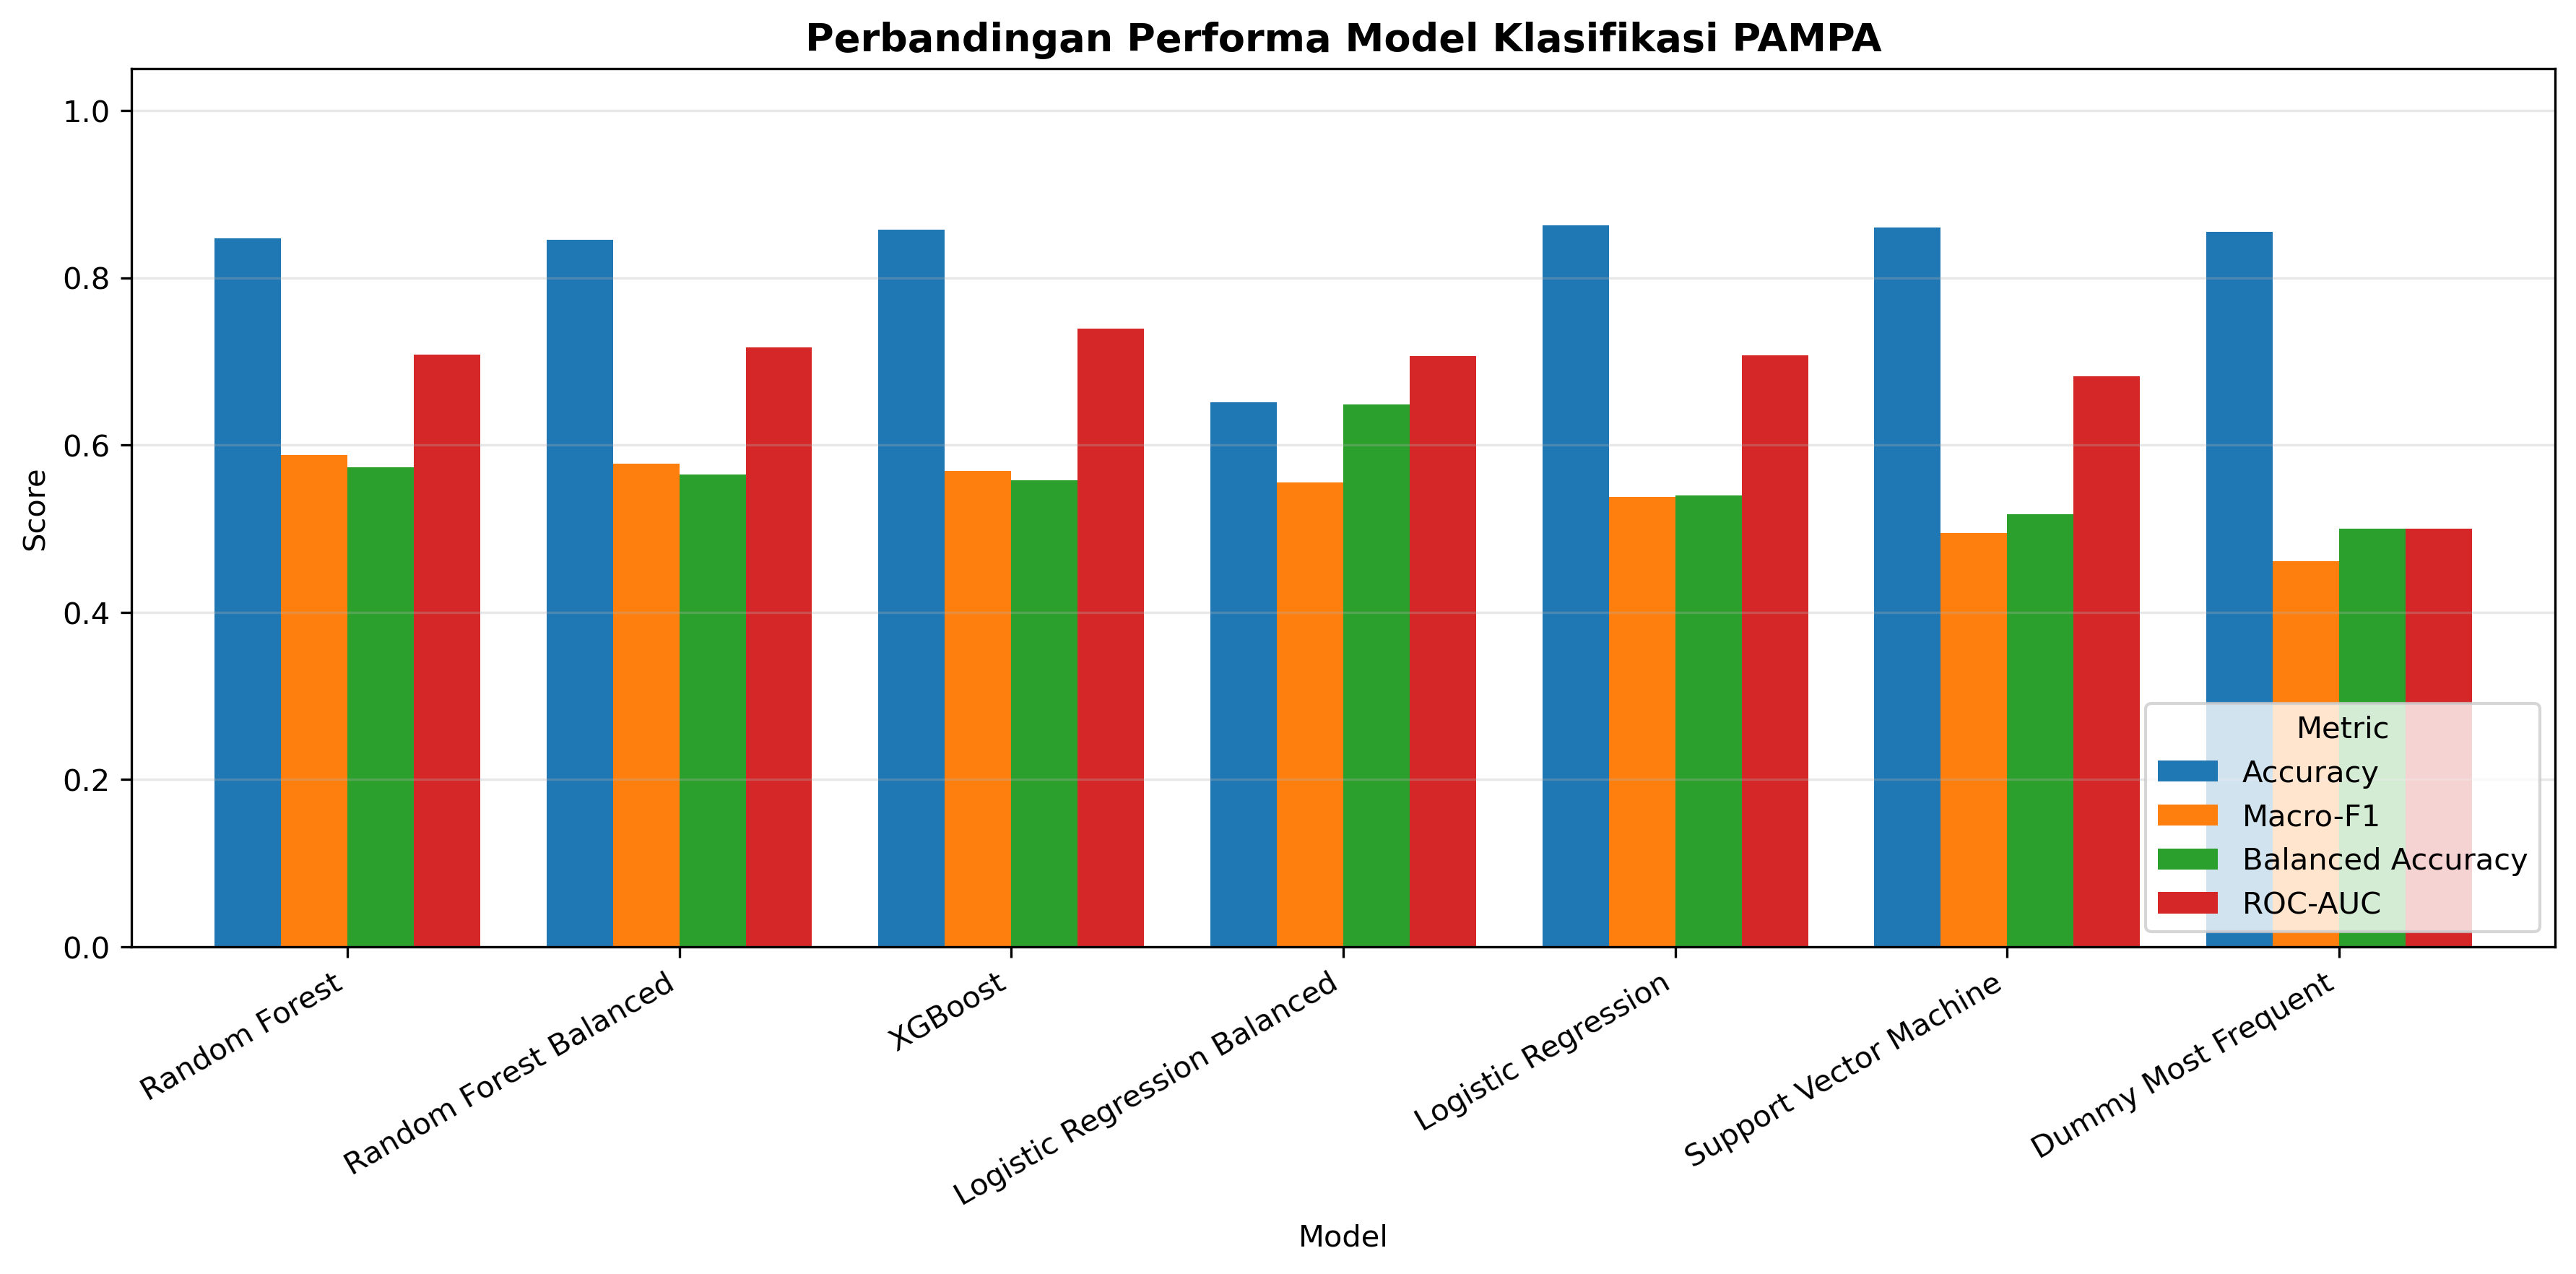

In [33]:
model_comparison_fig_path = RESULTS_FIGURES_DIR / "model_comparison.png"

if model_comparison_fig_path.exists():
    display(Image(filename=str(model_comparison_fig_path)))
else:
    print("model_comparison.png belum ditemukan.")

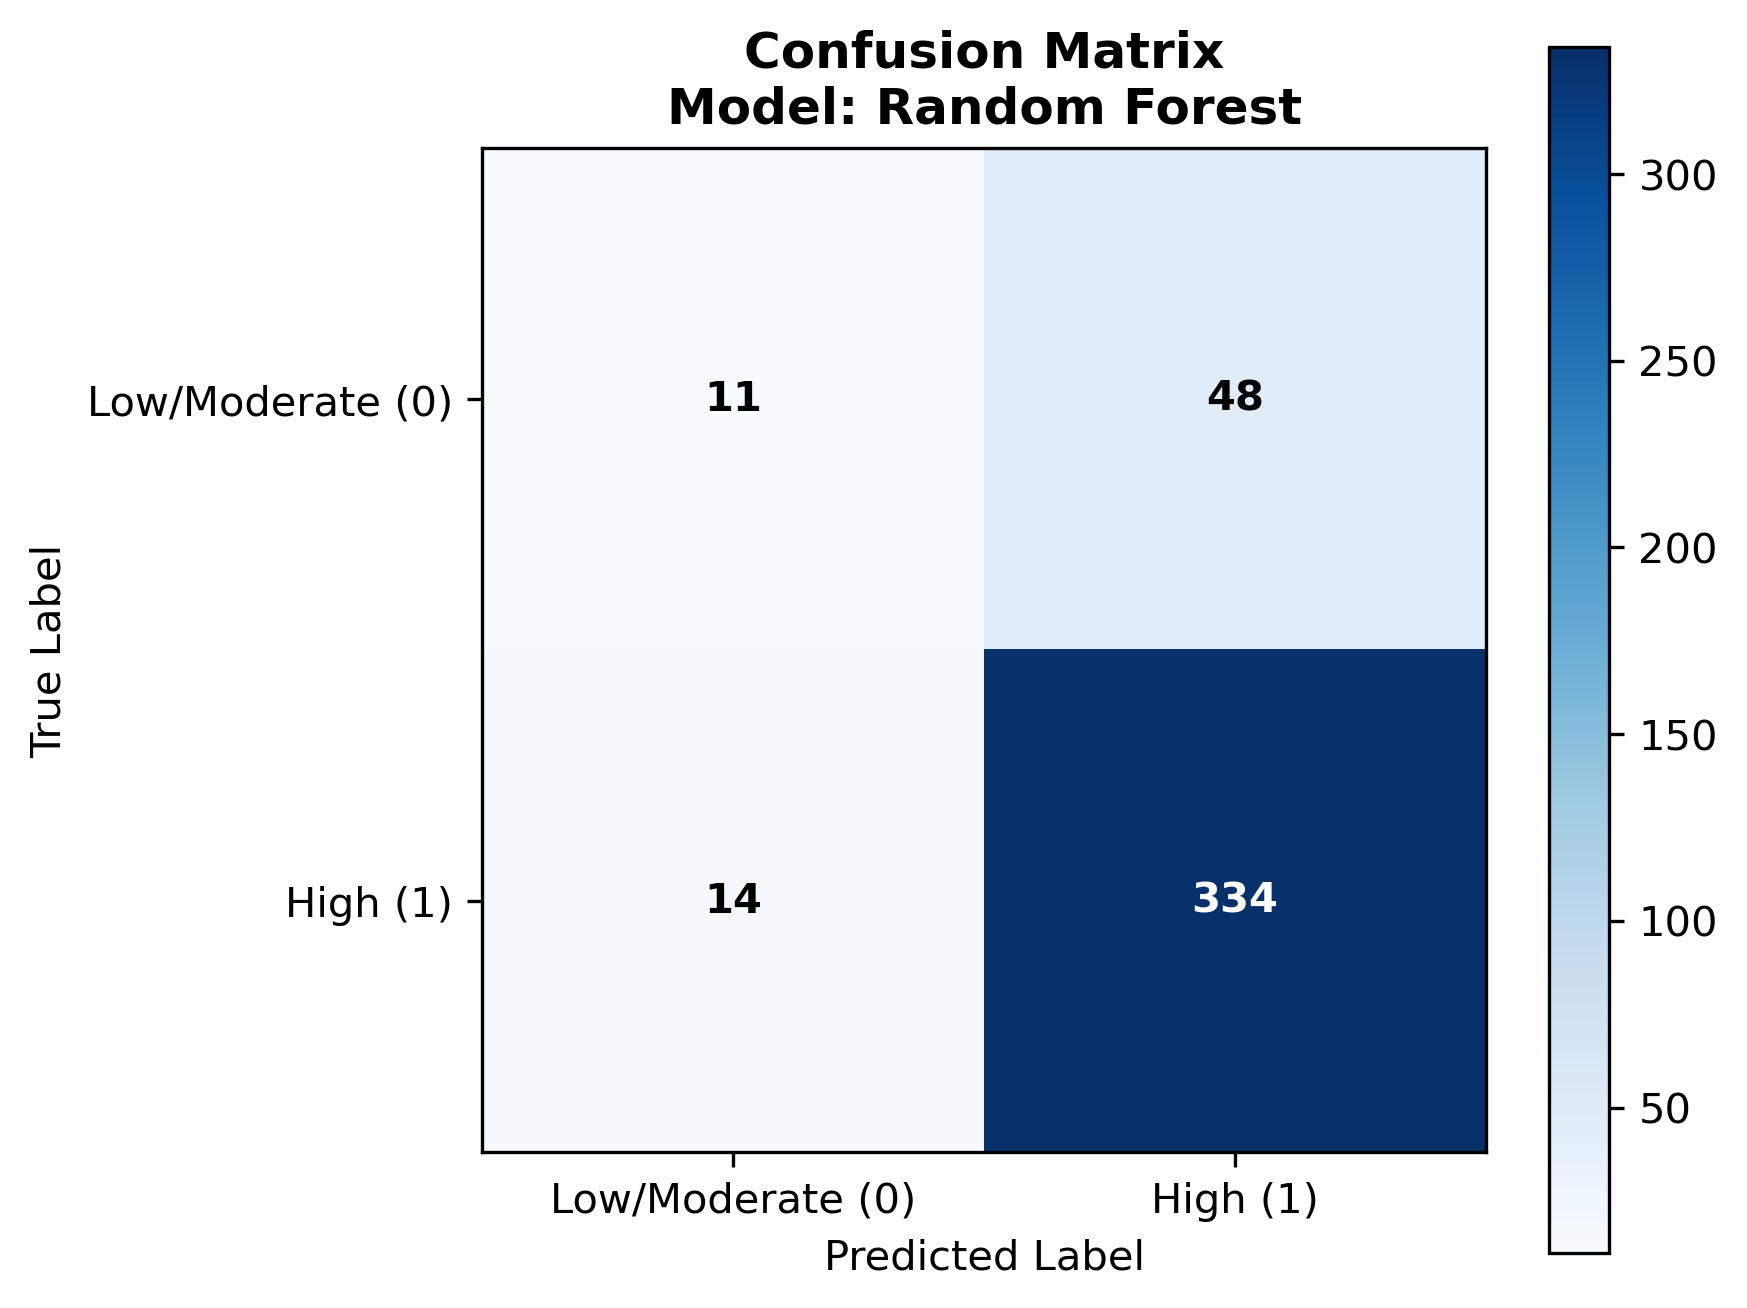

In [34]:
confusion_matrix_path = RESULTS_FIGURES_DIR / "confusion_matrix_best_model.png"

if confusion_matrix_path.exists():
    display(Image(filename=str(confusion_matrix_path)))
else:
    print("confusion_matrix_best_model.png belum ditemukan.")

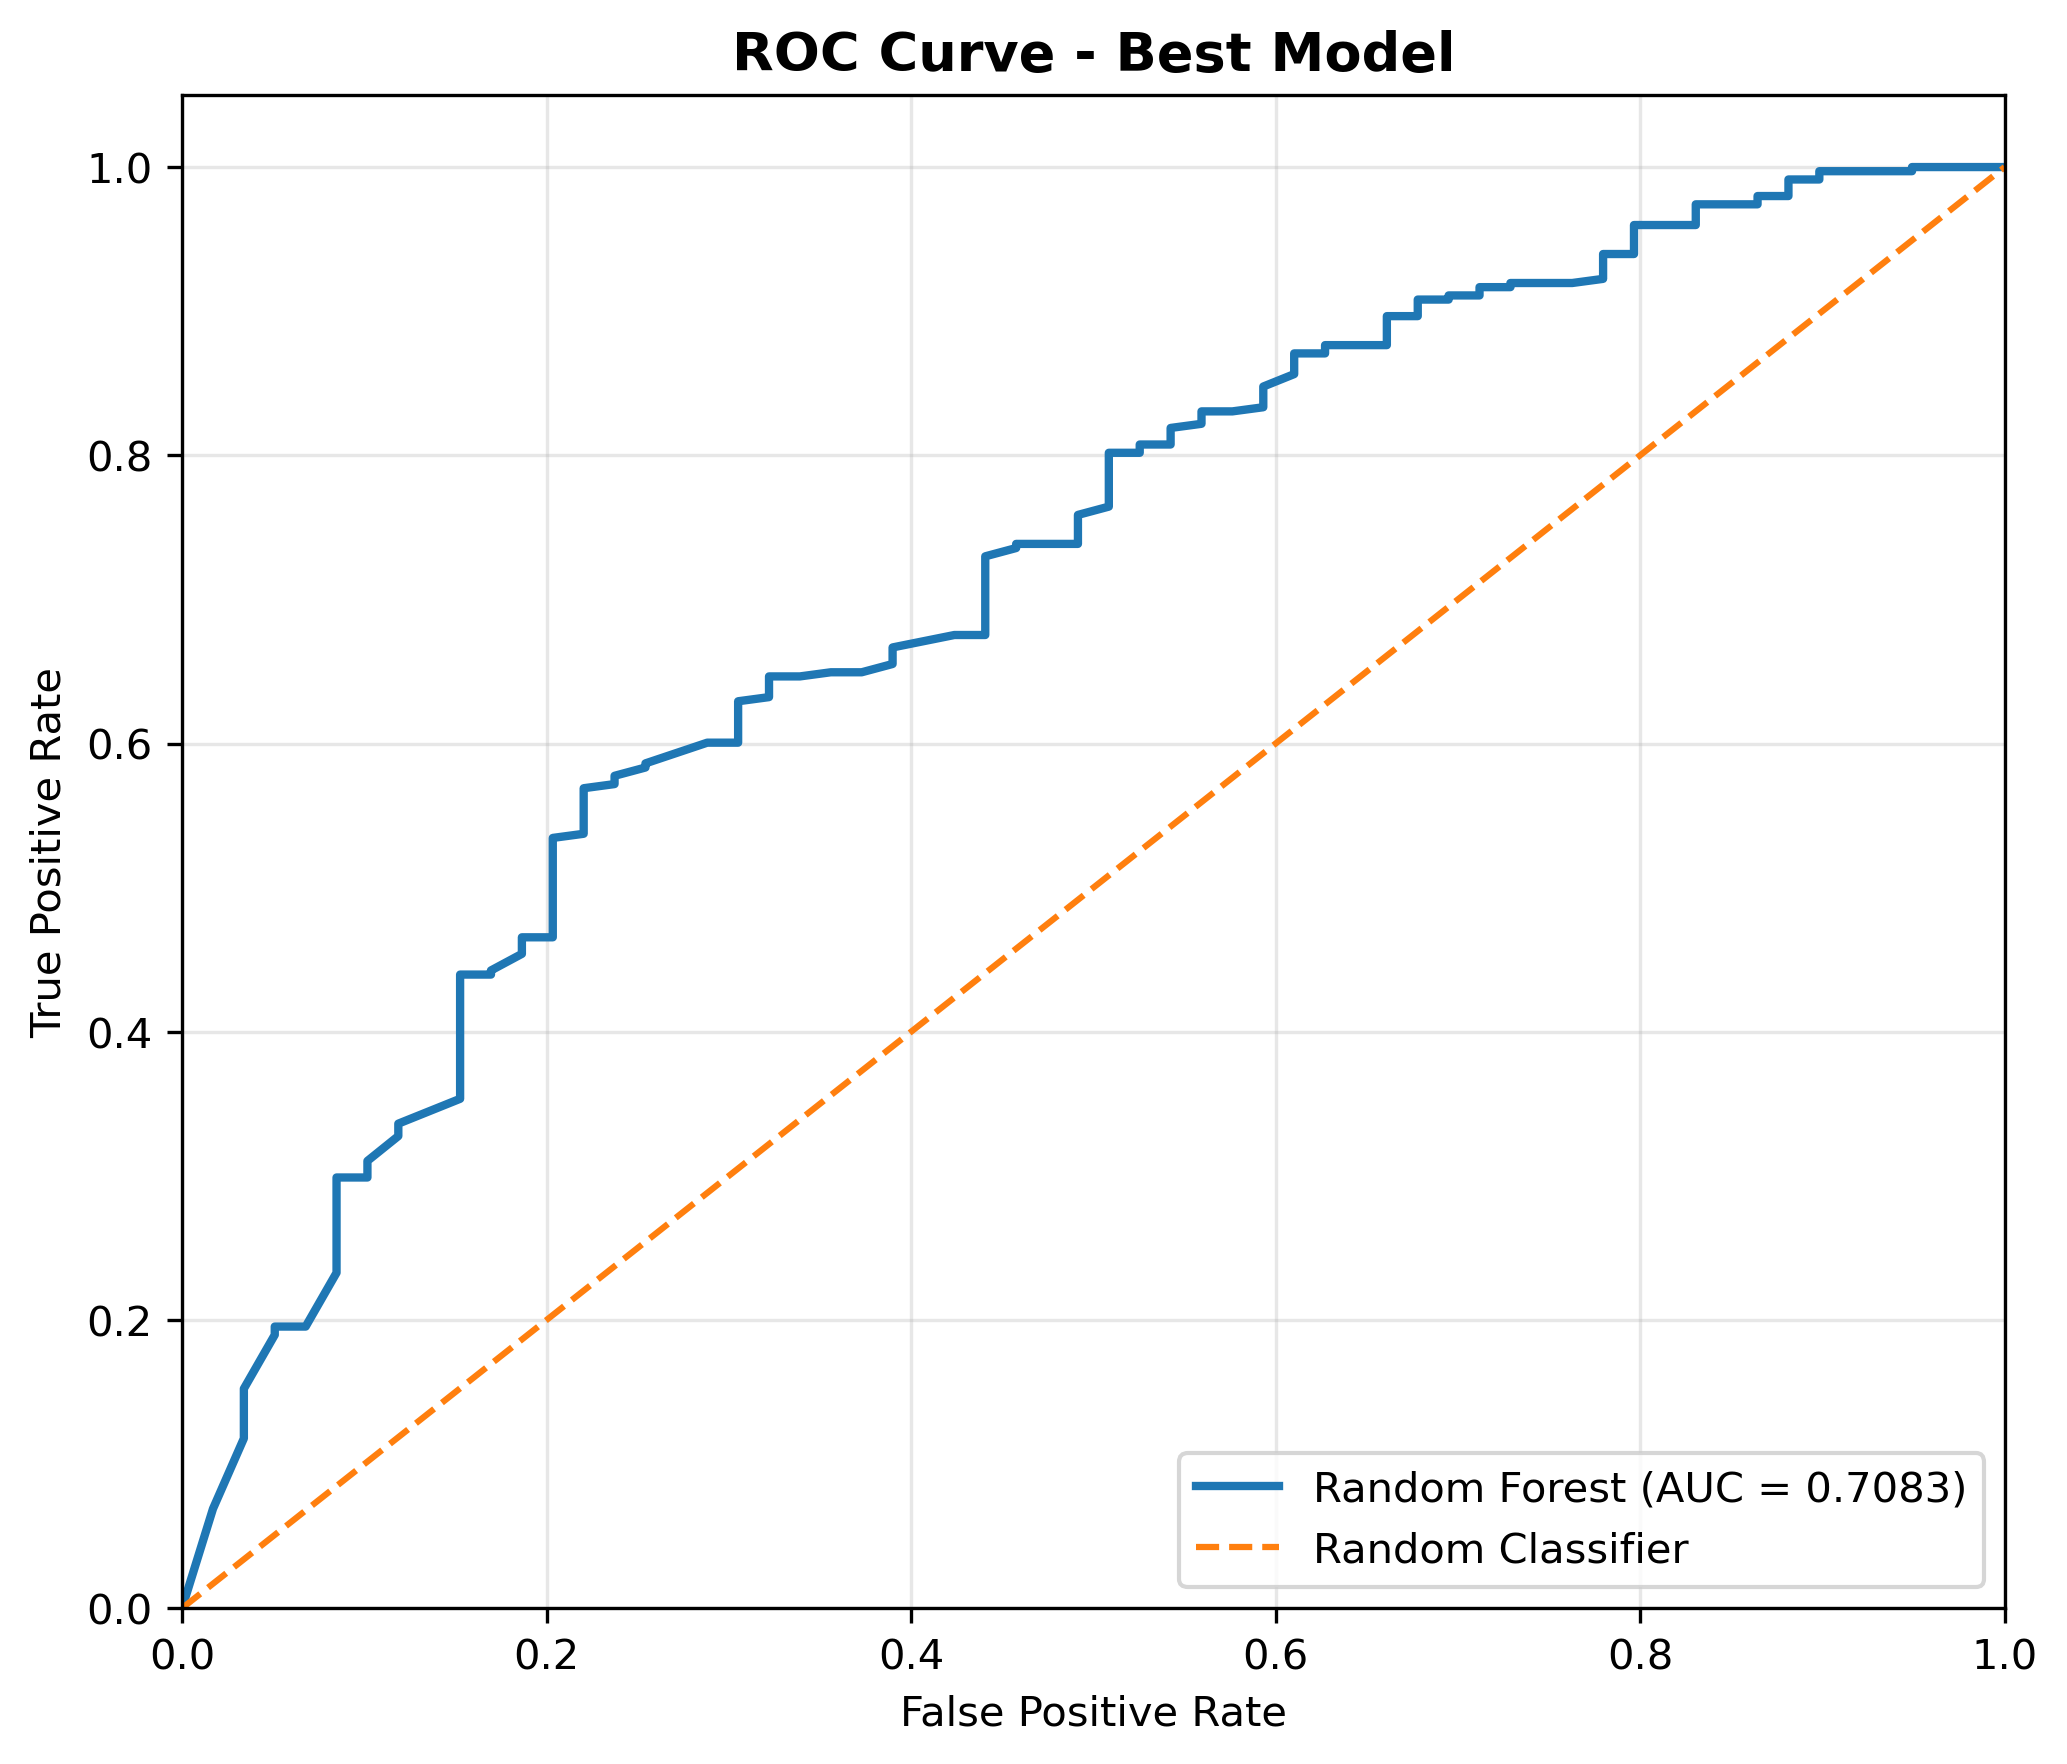

In [35]:
roc_curve_path = RESULTS_FIGURES_DIR / "roc_curve_best_model.png"

if roc_curve_path.exists():
    display(Image(filename=str(roc_curve_path)))
else:
    print("roc_curve_best_model.png belum ditemukan.")

**Catatan interpretasi evaluasi:**

Dari confusion matrix ini, terlihat bahwa model Random Forest cukup baik dalam mengenali molekul dengan permeabilitas tinggi, karena sebagian besar data kelas `High` berhasil diprediksi dengan benar. Namun, model masih kesulitan mengenali kelas `Low/Moderate`, karena masih ada banyak data kelas tersebut yang diprediksi sebagai `High`.

Hal ini menunjukkan adanya pengaruh class imbalance, karena jumlah data `High Permeability` jauh lebih dominan dibandingkan `Low/Moderate Permeability`. Karena itu, performa model tidak hanya dinilai dari accuracy, tetapi juga dari Macro-F1, Balanced Accuracy, recall kelas Low/Moderate, confusion matrix, dan ROC-AUC.

# 7. Model Interpretation

Bagian ini menjelaskan fitur mana yang paling berpengaruh terhadap prediksi model. Feature importance penting karena membantu menghubungkan hasil komputasi dengan konsep biologis membran.

Interpretasi umum:
- `LogP` tinggi menunjukkan molekul lebih lipofilik, sehingga lebih mudah berinteraksi dengan bagian hidrofobik lipid bilayer.
- `TPSA`, `HBD`, dan `HBA` tinggi menunjukkan karakter polar, sehingga molekul cenderung lebih sulit melewati inti hidrofobik membran.
- `MolWt` dan `HeavyAtomCount` berkaitan dengan ukuran/kompleksitas molekul.
- `FormalCharge` berkaitan dengan muatan molekul, yang umumnya menyulitkan permeasi pasif.

In [36]:
# Jalankan tahap 04: interpretation and prediction.
# Tahap ini menghitung feature importance dan melakukan demo prediksi SMILES baru.
%run src/04_interpretation_and_prediction.py

[INFO] Direktori output berhasil disiapkan.
[INFO] Best model dimuat: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\models\best_model.pkl
[INFO] Metadata best model dimuat: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\models\best_model_metadata.json
[INFO] Data fitur dimuat: C:\Users\SONYA PUTRI\Documents\Semester 6\KDS\Tubes\membrane-permeability-ml\data\processed\pampa_features.csv
[INFO] Shape data fitur: (2034, 12)
[INFO] Nama best model: Random Forest
[INFO] Data referensi importance memakai test set: (407, 9)
[INFO] Mengekstraksi feature importance dari model: RandomForestClassifier
[INFO] Importance menggunakan feature_importances_ bawaan model.
[INFO] Feature importance berhasil dihitung.

=== TOP FEATURE IMPORTANCE ===
       Feature  Raw_Importance  Importance         Importance_Source
          LogP        0.219706    1.000000 model_feature_importances
          TPSA        0.216646    0.986075 model_feature_impo

In [37]:
feature_importance_path = RESULTS_TABLES_DIR / "feature_importance.csv"

if feature_importance_path.exists():
    feature_importance = pd.read_csv(feature_importance_path)
    display(feature_importance.round(6))
else:
    print("feature_importance.csv belum ditemukan.")

,Feature,Raw_Importance,Importance,Signed_Effect,Importance_Source,Biological_Description
0,LogP,0.219706,1.000000,NaN,model_feature_importances,Lipofilisitas/hidrofobisitas. Nilai LogP yang ...
1,TPSA,0.216646,0.986075,NaN,model_feature_importances,Topological Polar Surface Area. Nilai TPSA yan...
2,MolWt,0.186289,0.847900,NaN,model_feature_importances,Berat molekul. Molekul yang lebih besar cender...
3,HeavyAtomCount,0.097928,0.445725,NaN,model_feature_importances,Jumlah atom non-hidrogen. Fitur ini berkaitan ...
4,HBD,0.082226,0.374256,NaN,model_feature_importances,Hydrogen bond donor. Jumlah donor ikatan hidro...
5,RotatableBonds,0.077103,0.350936,NaN,model_feature_importances,Jumlah ikatan yang dapat berotasi. Fitur ini m...
6,HBA,0.072512,0.330039,NaN,model_feature_importances,Hydrogen bond acceptor. Jumlah akseptor ikatan...
7,RingCount,0.047590,0.216608,NaN,model_feature_importances,Jumlah cincin dalam struktur molekul. Fitur in...
8,FormalCharge,0.000000,0.000000,NaN,model_feature_importances,Muatan formal molekul. Molekul bermuatan umumn...


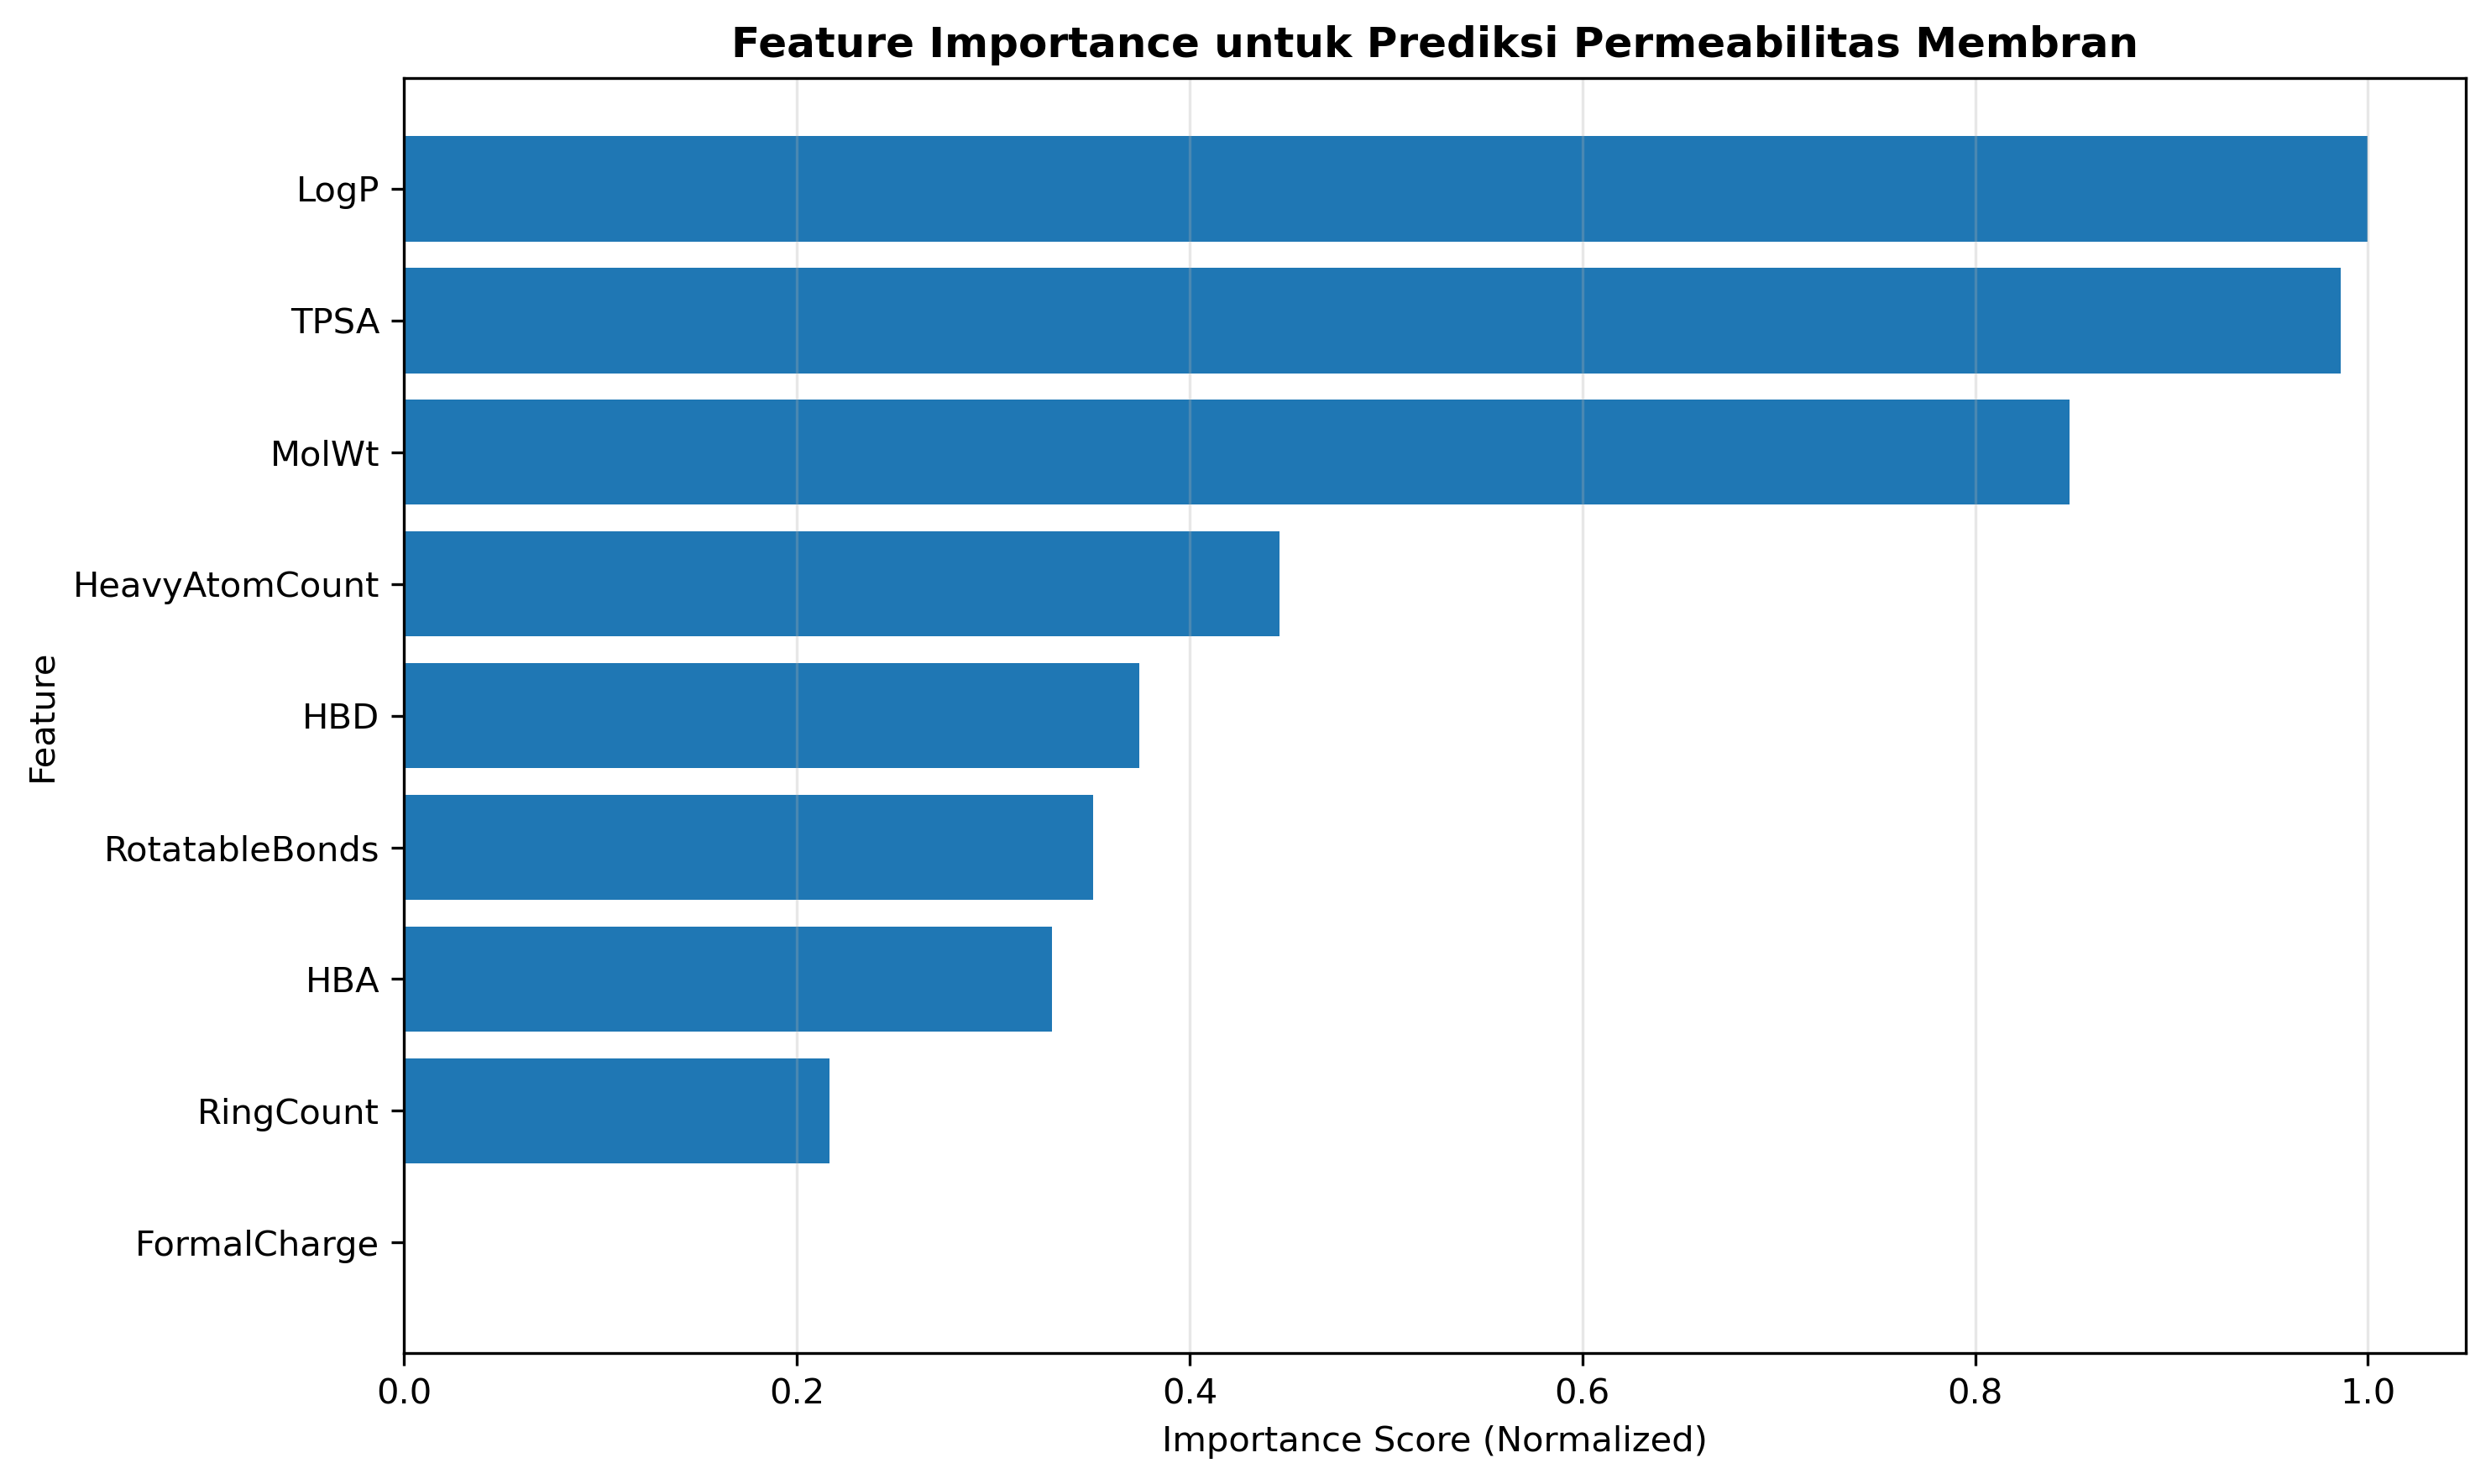

In [38]:
feature_importance_fig_path = RESULTS_FIGURES_DIR / "feature_importance.png"

if feature_importance_fig_path.exists():
    display(Image(filename=str(feature_importance_fig_path)))
else:
    print("feature_importance.png belum ditemukan.")

# 8. New SMILES Prediction

Bagian ini menunjukkan bahwa model dapat digunakan untuk memprediksi molekul baru dari input SMILES.

Alur prediksi:
1. user memberi SMILES;
2. RDKit memvalidasi SMILES;
3. RDKit menghitung deskriptor fisikokimia;
4. model terbaik memprediksi kelas permeabilitas;
5. program menampilkan probabilitas `High Permeability`.

Contoh molekul demo pada script `04`:
- Aspirin
- Caffeine
- Ibuprofen
- Ethanol
- Glucose

In [39]:
demo_predictions_path = RESULTS_TABLES_DIR / "demo_predictions.csv"

if demo_predictions_path.exists():
    demo_predictions = pd.read_csv(demo_predictions_path)

    columns_to_show = [
        "Molecule",
        "SMILES",
        "Prediction_Label",
        "Probability_High_Permeability",
        "Probability_Low_Moderate_Permeability",
        "MolWt",
        "LogP",
        "TPSA",
        "HBD",
        "HBA",
    ]

    available_columns = [col for col in columns_to_show if col in demo_predictions.columns]
    display(demo_predictions[available_columns])
else:
    print("demo_predictions.csv belum ditemukan.")

,Molecule,SMILES,Prediction_Label,Probability_High_Permeability,Probability_Low_Moderate_Permeability,MolWt,LogP,TPSA,HBD,HBA
0,Aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,High Permeability,0.9700,0.0300,180.159,1.3101,63.60,1,3
1,Caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,High Permeability,0.6350,0.3650,194.194,-1.0293,61.82,0,3
2,Ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,High Permeability,0.7950,0.2050,206.285,3.0732,37.30,1,1
3,Ethanol,CCO,High Permeability,0.5500,0.4500,46.069,-0.0014,20.23,1,1
4,Glucose,C(C1C(C(C(C(O1)O)O)O)O)O,Low/Moderate Permeability,0.2525,0.7475,180.156,-3.2214,110.38,5,6


# 9. Conclusion

Berdasarkan demo pipeline:

1. Dataset PAMPA_NCATS berhasil dimuat sebagai data klasifikasi biner permeabilitas molekul.
2. Struktur molekul dalam format SMILES berhasil divalidasi dan diubah menjadi deskriptor fisikokimia menggunakan RDKit.
3. Beberapa model machine learning berhasil dilatih dan dibandingkan.
4. Karena dataset tidak seimbang, evaluasi tidak hanya menggunakan accuracy, tetapi juga Macro-F1, Balanced Accuracy, ROC-AUC, Recall per kelas, dan Confusion Matrix.
5. Model terbaik pada hasil demo adalah model dengan kombinasi performa paling baik berdasarkan metrik yang lebih adil untuk data imbalance.
6. Feature importance menunjukkan fitur fisikokimia yang paling berpengaruh terhadap prediksi, misalnya LogP, TPSA, MolWt, atau fitur lain sesuai hasil running.
7. Secara biologis, fitur-fitur tersebut relevan dengan permeabilitas pasif lipid bilayer karena berkaitan dengan lipofilisitas, polaritas, ukuran, fleksibilitas, dan muatan molekul.
8. Demo prediksi SMILES baru menunjukkan bahwa pipeline dapat digunakan untuk memperkirakan kelas permeabilitas molekul baru.